## Bkg plots for combine

In [1]:
#### python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
import coffea.util
from matplotlib.colors import LogNorm
from coffea.processor import accumulate

In [2]:
# client = scaleout.make_dask_client("tls://localhost:8786")
# client

In [10]:
# Parameters
vr = "23"
nfiles = -1

In [11]:
# Samples
sig_2mu = [
    "2Mu2E_200GeV_5p0GeV_100p0mm", #changing MXX
    "2Mu2E_500GeV_5p0GeV_80p0mm",
    "2Mu2E_800GeV_5p0GeV_50p0mm",
    "2Mu2E_1000GeV_5p0GeV_40p0mm",
    
    "2Mu2E_500GeV_0p25GeV_4p0mm", #changing MZd
    "2Mu2E_500GeV_1p2GeV_19p0mm",

    "2Mu2E_500GeV_1p2GeV_0p019mm", #changing Lxy
    "2Mu2E_500GeV_1p2GeV_0p19mm",
    "2Mu2E_500GeV_1p2GeV_1p9mm",
    "2Mu2E_500GeV_1p2GeV_9p6mm",
    "2Mu2E_500GeV_1p2GeV_19p0mm", 
]

sig_4mu = [
    "4Mu_200GeV_5p0GeV_200p0mm",
    "4Mu_500GeV_5p0GeV_80p0mm",
    "4Mu_800GeV_5p0GeV_50p0mm",
    "4Mu_1000GeV_5p0GeV_40p0mm",

    "4Mu_500GeV_0p25GeV_0p004mm",
    "4Mu_500GeV_1p2GeV_19p0mm",

    "4Mu_500GeV_1p2GeV_0p019mm",
    "4Mu_500GeV_1p2GeV_0p19mm",
    "4Mu_500GeV_1p2GeV_1p9mm",
    "4Mu_500GeV_1p2GeV_9p6mm",
    "4Mu_500GeV_1p2GeV_19p0mm",
]

bkgdyj = [
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
]

bkgttj = [
    "TTJets"]

bkgqcd = [
    "QCD_Pt15To20",
    "QCD_Pt20To30",
    "QCD_Pt30To50",
    "QCD_Pt50To80",
    "QCD_Pt80To120",
]

bkgocd = [
    "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
    "QCD_Pt470To600",
    "QCD_Pt600To800",
    "QCD_Pt800To1000", 
    "QCD_Pt1000",       
]

mxx2 = sig_2mu[:4]
mzd2 = [sig_2mu[4:6], sig_2mu[1]]
lxy2 = sig_2mu[7:]

mxx4 = sig_4mu[:4]
mzd4 = [sig_4mu[4:6], sig_4mu[1]]
lxy4 = sig_4mu[7:]

[[], '4Mu_1000GeV_5p0GeV_40p0mm']
[[], '2Mu2E_1000GeV_5p0GeV_40p0mm']


In [12]:
#channels: cuts to be applied (slections.yaml) 
channels = ["baseNoLj", 
            "bkg_iso",
            "bkg_iso_disp",
            "bkg_iso_disp_2lj",
            "bkg_iso_disp_2lj_2mu2e",
            "bkg_iso_disp_2lj_4mu",
            "bkg_iso_disp_2lj_2mu2e_dphi",
            "bkg_iso_disp_2lj_4mu_dphi",
           ]

ch1 = channels[0] #base
ch2 = channels[1] # iso
ch3 = channels[2] # iso + disp
ch4 = channels[3] # iso + disp + 2lj
ch5 = channels[4] # iso + disp + 2lj + 2mu2e
ch6 = channels[5] # iso + disp + 2lj + 4mu
ch7 = channels[6] # iso + disp + 2lj + 2mu2e + dphi
ch8 = channels[7] # iso + disp + 2lj + 4mu + dphi

cha = [ch1, ch2, ch3, ch4, ch5, ch6, ch7, ch8]
# ch3 = channels[2] # 2lj
# ch4 = channels[3] # dphi2 4mu
# ch5 = channels[4] # dphi2 2mu
# ch6 = channels[5] # dphi2.2 2mu
# ch7 = channels[6] # dphi2.2 2mu

## Stop here for plotting

In [6]:
runner = processor.Runner(
    executor=processor.FuturesExecutor(),                # for testing locally
    # executor=processor.IterativeExecutor(),
    # executor=processor.DaskExecutor(client=client),    # for dask
    # schema=NanoAODSchema,
    schema = llpnanoaodschema.LLPNanoAODSchema,
    # maxchunks=1,
    skipbadfiles=True,
   
)

p = sidm_processor.SidmProcessor(
    channels,
    ["BKG_study"],
    unweighted_hist=True, verbose=False
    # verbose=True,
)

In [7]:
# process 2mu2e

fileset_2mu = utilities.make_fileset(sig_2mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_2mu2e_v10.yaml")
out_2mu = runner.run(fileset_2mu, treename="Events", processor_instance=p)
out_2mu = out_2mu["out"]
# coffea.util.save(out_sig2, "outputs/BKG_sig2mu_" + vr + ".coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


2Mu2E_800GeV_5p0GeV_50p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
2Mu2E_1000GeV_5p0GeV_40p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [8]:
#process 4mu
fileset_4mu = utilities.make_fileset(sig_4mu, "llpNanoAOD_v2", max_files = nfiles, location_cfg="signal_4mu_v10.yaml")
out_4mu = runner.run(fileset_4mu, treename="Events", processor_instance=p)
out_4mu = out_4mu["out"]
# coffea.util.save(out_4mu, "outputs/gen_4mu.coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


4Mu_800GeV_5p0GeV_50p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb
4Mu_1000GeV_5p0GeV_40p0mm is simulation. Scaling histograms or cutflows according to lumi*xs.
Signal not in xs cfg, assuming 1fb


In [ ]:
# nfiles = 

In [9]:
fileset_dyj = utilities.make_fileset(bkgdyj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
out_dyj     = runner.run(fileset_dyj, treename="Events", processor_instance=p)
out_dyj     = out_dyj["out"]
# coffea.util.save(out_dyj, "outputs/BKG_bkgdyj_" + vr + ".coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


DYJetsToMuMu_M10to50 is simulation. Scaling histograms or cutflows according to lumi*xs.
DYJetsToMuMu_M50 is simulation. Scaling histograms or cutflows according to lumi*xs.


In [10]:
# Process ttj

fileset_ttj = utilities.make_fileset(bkgttj, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
out_ttj     = runner.run(fileset_ttj, treename="Events", processor_instance=p)
out_ttj     = out_ttj["out"]
# coffea.util.save(out_bkg_ttj, "outputs/BKG_bkgttj_" + vr + ".coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.


In [11]:
# process qcd

fileset_qcd    = utilities.make_fileset(bkgqcd, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
out_qcd        = runner.run(fileset_qcd, treename="Events", processor_instance=p)
out_qcd    = out_qcd["out"]
# coffea.util.save(out_bkg_qcd, "outputs/BKG_bkgqcd_" + vr + ".coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


QCD_Pt15To20 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt20To30 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt30To50 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt50To80 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt80To120 is simulation. Scaling histograms or cutflows according to lumi*xs.


In [12]:
# bkg qcd2

fileset_ocd    = utilities.make_fileset(bkgocd, "skimmed_llpNanoAOD_v2", max_files = nfiles, location_cfg = "backgrounds.yaml",)
out_ocd        = runner.run(fileset_ocd, treename="Events", processor_instance=p)
out_ocd        = out_ocd["out"]
# coffea.util.save(out_bkg_ocd, "outputs/BKG_bkgocd_" + vr + ".coffea")

Output()

Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(
/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(


/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: overflow encountered in power
  return impl(*broadcasted_args, **(kwargs or {}))
/usr/local/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: overflow encountered in multiply
  return impl(*broadcasted_args, **(kwargs or {}))


QCD_Pt120To170 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt170To300 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt300To470 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt470To600 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt600To800 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt800To1000 is simulation. Scaling histograms or cutflows according to lumi*xs.
QCD_Pt1000 is simulation. Scaling histograms or cutflows according to lumi*xs.


In [29]:
out_all = out_2mu | out_4mu | out_dyj | out_ttj | out_qcd | out_ocd
# out_all = out_2mu | out_4mu# | out_dyj | out_ttj | out_qcd | out_ocd
coffea.util.save(out_all, "outputs/bkg_" + vr + ".coffea")

# Start plotting

In [16]:
output = coffea.util.load("outputs/bkg_"+ vr +".coffea")

lab_mx = ["200", "500", "800", "1000"]
lab_xy = ["0.3", "3.0", "30", "150", "300"]
lab_zd = ["0.25", "1.2", "5.0"]

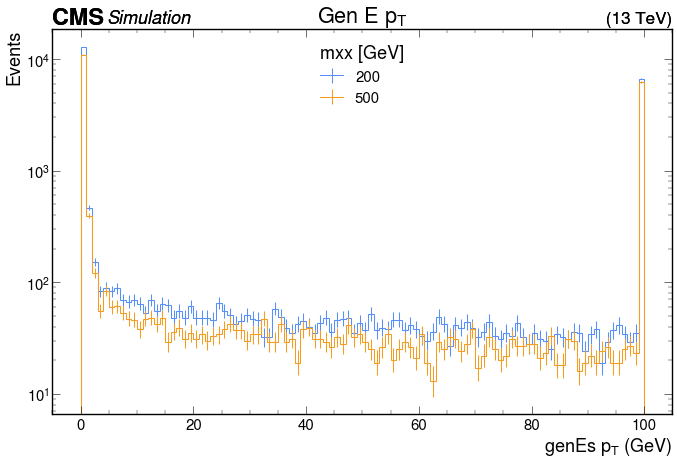

In [18]:
# Gen Electron Variables 2mu
htplot = ["genE_pt",
          # "electron_pt",
          # "muon_dxy",
          # "electron_pt",
          # "dsaMuon_pt"
          # "dsaMuon_dxy"
          # "muon_muon_dR",
         ]

htname = [r"Gen E $p_T$",
          # r"Ele $p_T$",
          # r"Muon $d_0$",
          # r"ele $p_T$",
          # r"dsamu $p_T$",
          # r"dsamu $d_0$",
          # r"Muon $\Delta R$",
         ]

# changing Bs
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx2):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_bkg_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing zd
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mzd4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing lxy
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(lxy4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

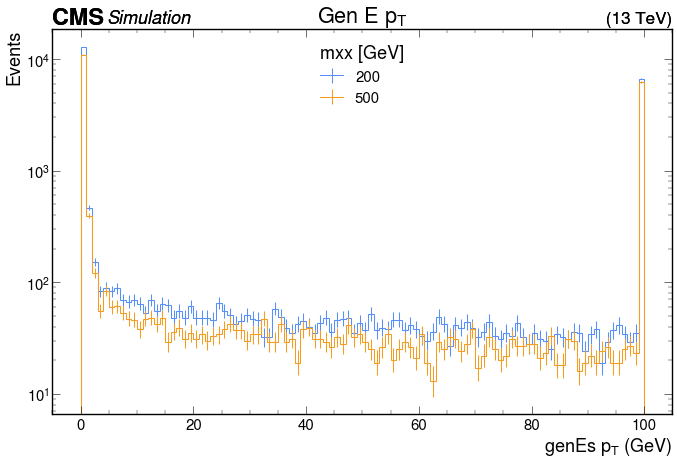

In [18]:
# Gen Muons Variables 2mu
htplot = ["genMu_pt",
          # "electron_pt",
          # "muon_dxy",
          # "electron_pt",
          # "dsaMuon_pt"
          # "dsaMuon_dxy"
          # "muon_muon_dR",
         ]

htname = [r"Gen Mu $p_T$",
          # r"Ele $p_T$",
          # r"Muon $d_0$",
          # r"ele $p_T$",
          # r"dsamu $p_T$",
          # r"dsamu $d_0$",
          # r"Muon $\Delta R$",
         ]

# changing Bs
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx2):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_bkg_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing zd
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mzd4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing lxy
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(lxy4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

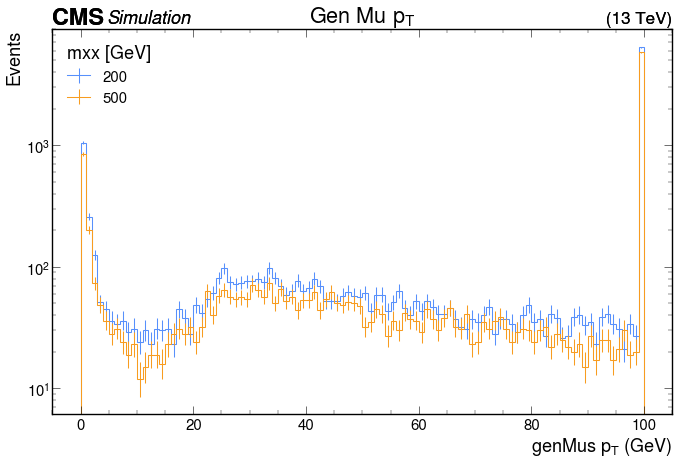

In [20]:
# Gen Muons Variables 4mu
htplot = ["genMu_pt",
          # "electron_pt",
          # "muon_dxy",
          # "electron_pt",
          # "dsaMuon_pt"
          # "dsaMuon_dxy"
          # "muon_muon_dR",
         ]

htname = [r"Gen Mu $p_T$",
          # r"Ele $p_T$",
          # r"Muon $d_0$",
          # r"ele $p_T$",
          # r"dsamu $p_T$",
          # r"dsamu $d_0$",
          # r"Muon $\Delta R$",
         ]

# changing Bs
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx2):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_bkg_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing zd
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mzd4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing lxy
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(lxy4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

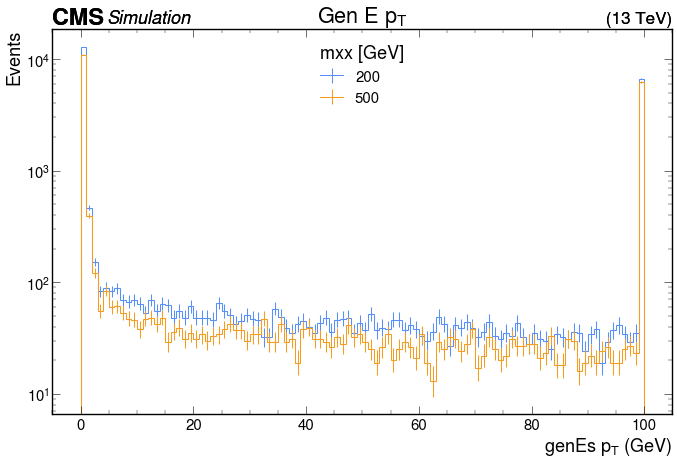

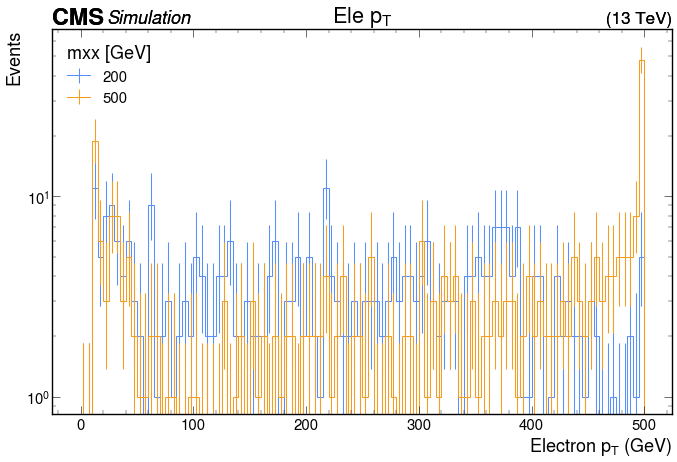

In [15]:
# Electron Variables 2mu2e
htplot = ["genE_pt",
          "electron_pt",
          # "muon_dxy",
          # "electron_pt",
          # "dsaMuon_pt"
          # "dsaMuon_dxy"
          # "muon_muon_dR",
         ]

htname = [r"Gen E $p_T$",
          r"Ele $p_T$",
          # r"Muon $d_0$",
          # r"ele $p_T$",
          # r"dsamu $p_T$",
          # r"dsamu $d_0$",
          # r"Muon $\Delta R$",
         ]

# changing Bs
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx2):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_bkg_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing zd
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mzd4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing lxy
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(lxy4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

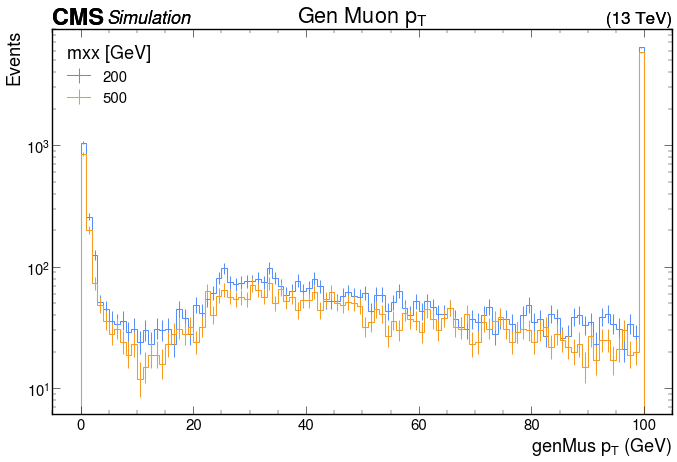

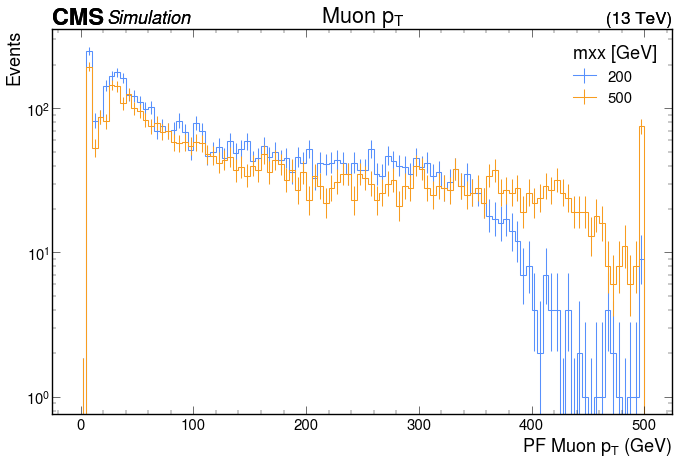

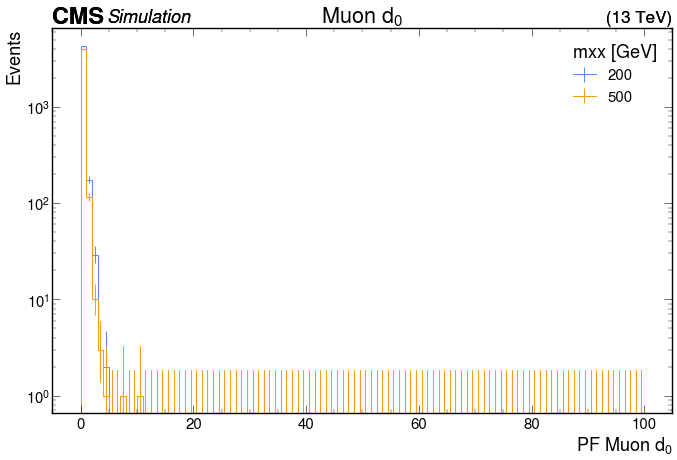

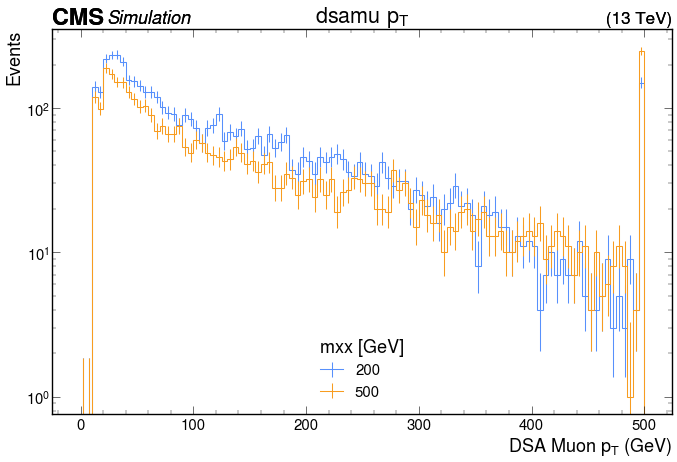

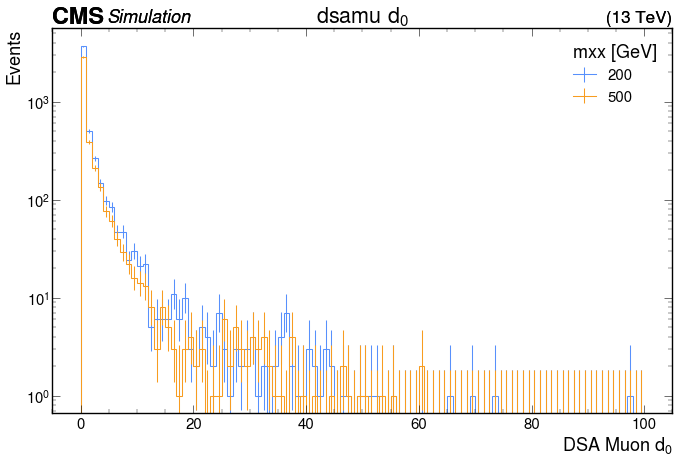

In [71]:
# Muon Variables 2mu
htplot = ["genMu_pt",
          "muon_pt",
          "muon_dxy",
          # "electron_pt",
          "dsaMuon_pt",
          "dsaMuon_dxy",
          # "muon_muon_dR",
         ]

htname = [r"Gen Muon $p_T$",
          r"Muon $p_T$",
          r"Muon $d_0$",
          # r"ele $p_T$",
          r"dsamu $p_T$",
          r"dsamu $d_0$",
          # r"Muon $\Delta R$",
         ]

# changing Bs
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx2):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_bkg_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing zd
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mzd4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing lxy
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(lxy4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

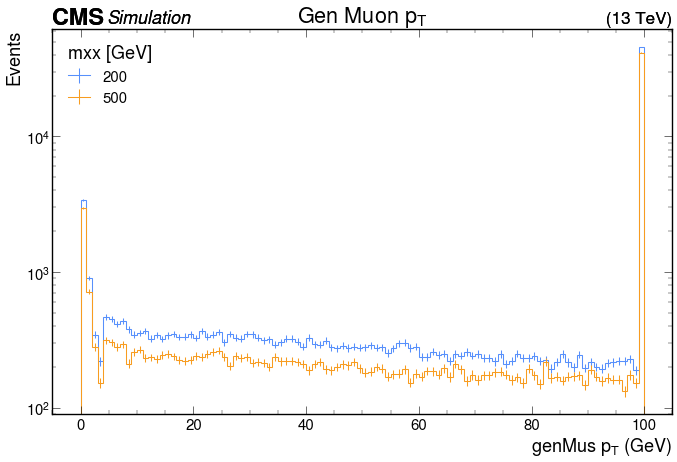

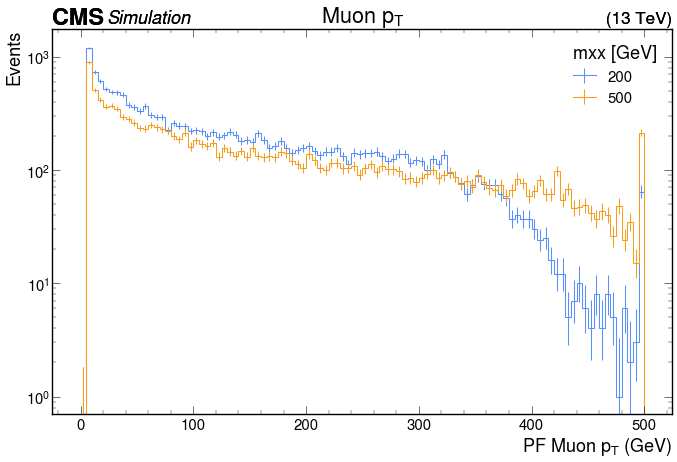

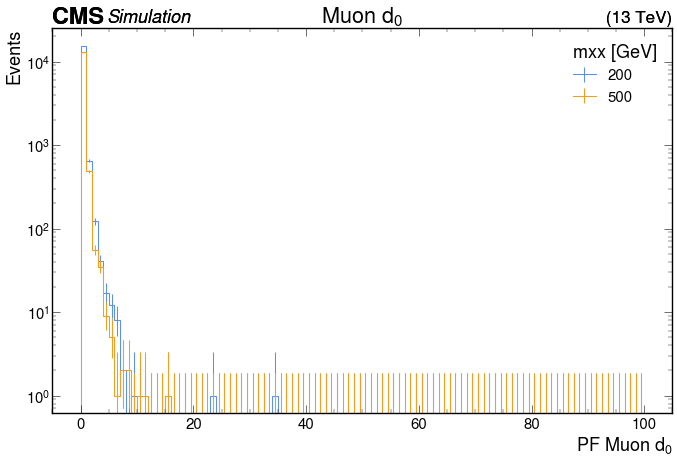

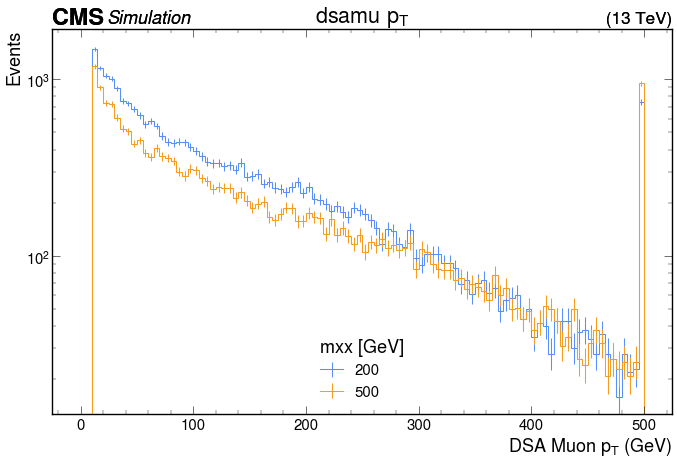

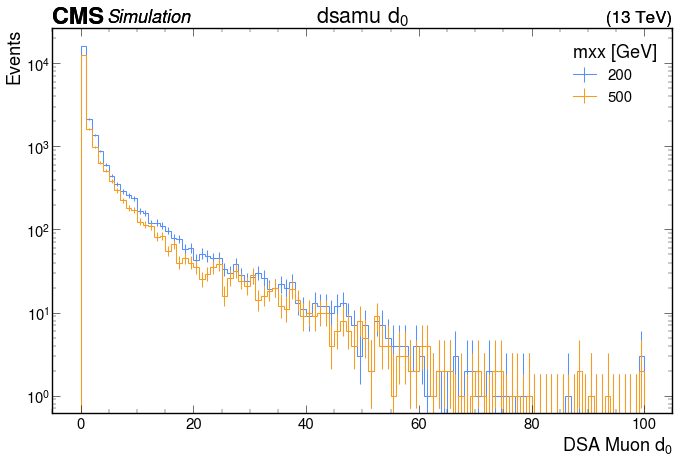

In [72]:
# Muon Variables 4mu
htplot = ["genMu_pt",
          "muon_pt",
          "muon_dxy",
          # "electron_pt",
          "dsaMuon_pt",
          "dsaMuon_dxy",
          # "muon_muon_dR",
         ]

htname = [r"Gen Muon $p_T$",
          r"Muon $p_T$",
          r"Muon $d_0$",
          # r"ele $p_T$",
          r"dsamu $p_T$",
          r"dsamu $d_0$",
          # r"Muon $\Delta R$",
         ]

# changing Bs
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx4):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_bkg_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing zd
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mzd4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing lxy
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(lxy4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

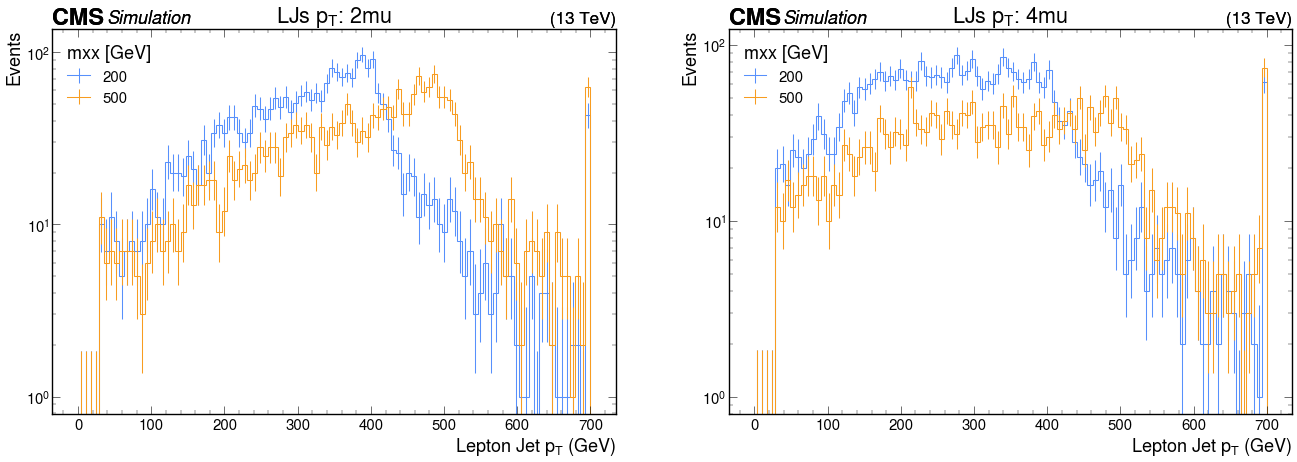

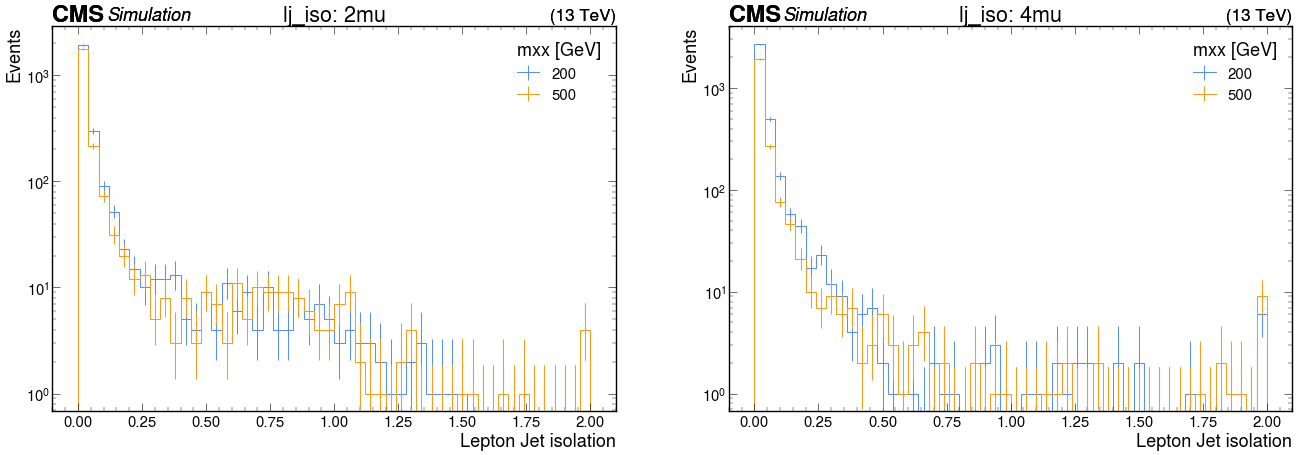

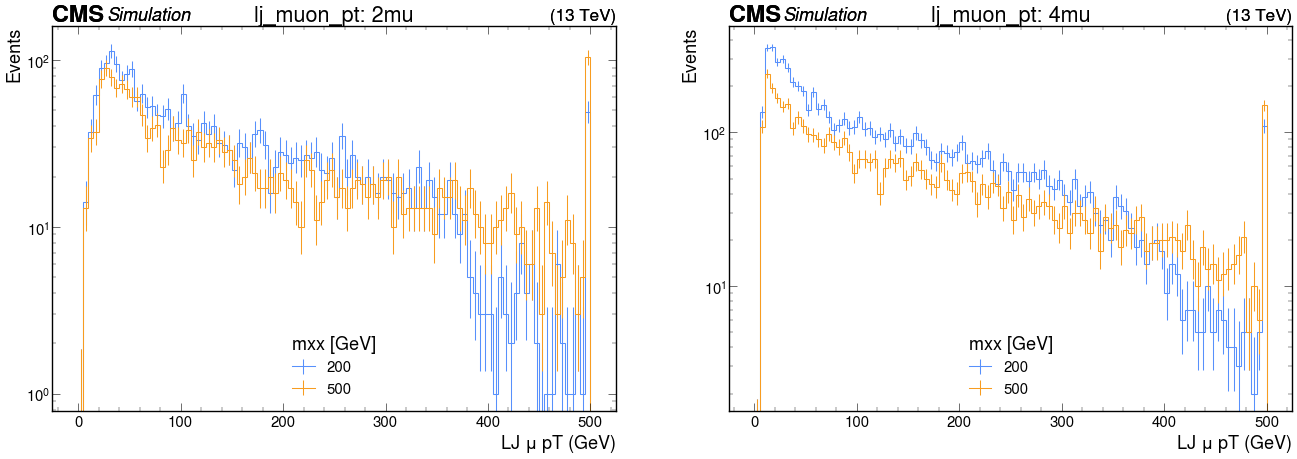

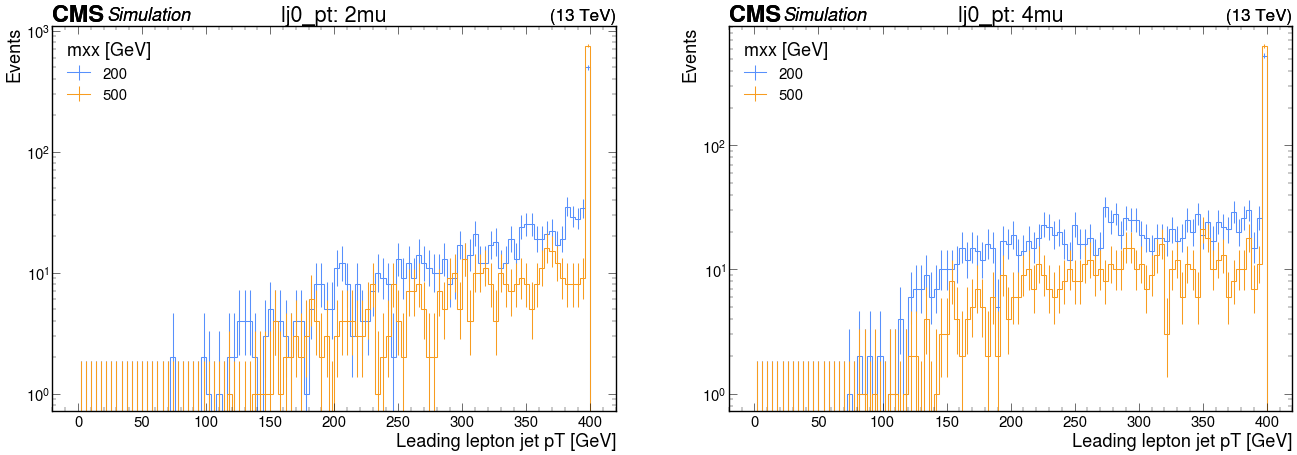

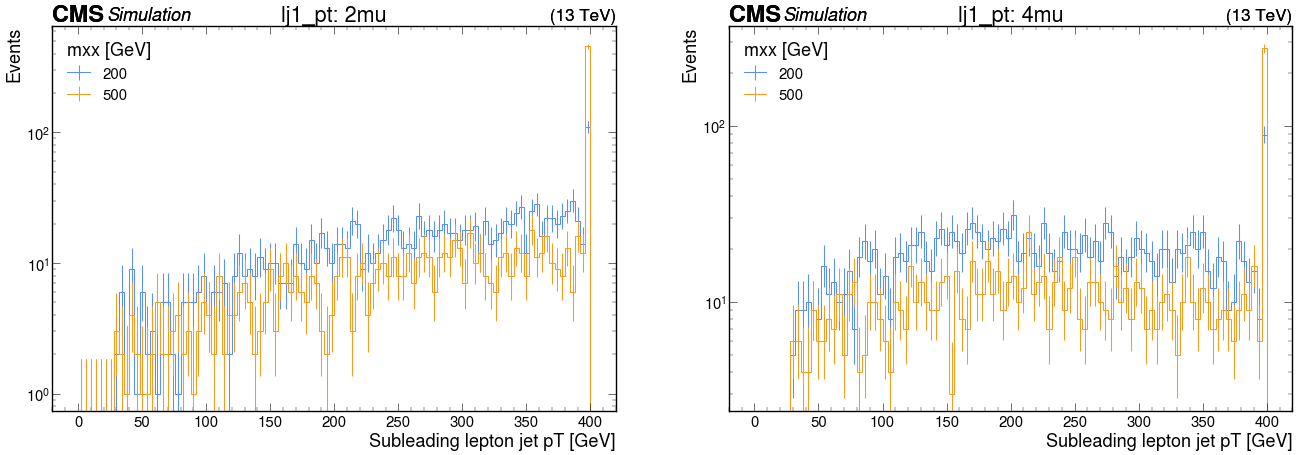

In [14]:
# LJ Variables signal only

htplot = ["lj_pt",
          "lj_iso",
          "lj_muon_pt",
          "lj0_pt",
          "lj1_pt",
#  "lj_e",
#  "lj0_e",
#  "lj1_e",
#  "lj0_dRSpread",
#  "lj1_dRSpread",
#  "lj_electronN",
#  "lj_photonN",
#  "lj_electronPhotonN",
#  "lj_muonN",
#  "lj_dsaMuN",
#  "lj_pfMuN",
#  "lj_muon_pt",
#  "lj_pfMuon_pt",
# "lj_dsaMuon_pt",
#  "lj_electron_pt",
#  "lj_photon_pt",
#  "lj_muon_dxy",
#  "lj_pfMuon_dxy",
#  "lj_dsaMuon_dxy",
#  "lj_dsaMuon_dz",
#  "lj_electron_dxy",
         ]

htname = [r"LJs $p_T$",
          "lj_iso",
          "lj_muon_pt",
          "lj0_pt",
          "lj1_pt",
#  "lj_e",
#  "lj0_e",
#  "lj1_e",
#  "lj0_dRSpread",
#  "lj1_dRSpread",
#  "lj_electronN",
#  "lj_photonN",
#  "lj_electronPhotonN",
#  "lj_muonN",
#  "lj_dsaMuN",
#  "lj_pfMuN",
#  "lj_muon_pt",
#  "lj_pfMuon_pt",
# "lj_dsaMuon_pt",
#  "lj_electron_pt",
#  "lj_photon_pt",
#  "lj_muon_dxy",
#  "lj_pfMuon_dxy",
#  "lj_dsaMuon_dxy",
#  "lj_dsaMuon_dz",
#  "lj_electron_dxy",
          # r"LJs $\Delta \Phi$",
          # r"LJs $\Delta R$",
          # r"LJs $\eta$",
         ]

# changing Bs 4mu
for ik, ht in enumerate(htplot):
    plt.subplots(1, 2, figsize=(32, 10))

    plt.subplot(1, 2, 1)
    for ij, sss in enumerate(mxx2):
        utilities.plot(output[sss]["hists"][ht][ch7, :], label = lab_mx[ij])
    plt.title(htname[ik]+": 2mu")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)

    plt.subplot(1, 2, 2)
    for ij, sss in enumerate(mxx4):
        utilities.plot(output[sss]["hists"][ht][ch8, :], label = lab_mx[ij])

    plt.title(htname[ik]+": 4mu")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

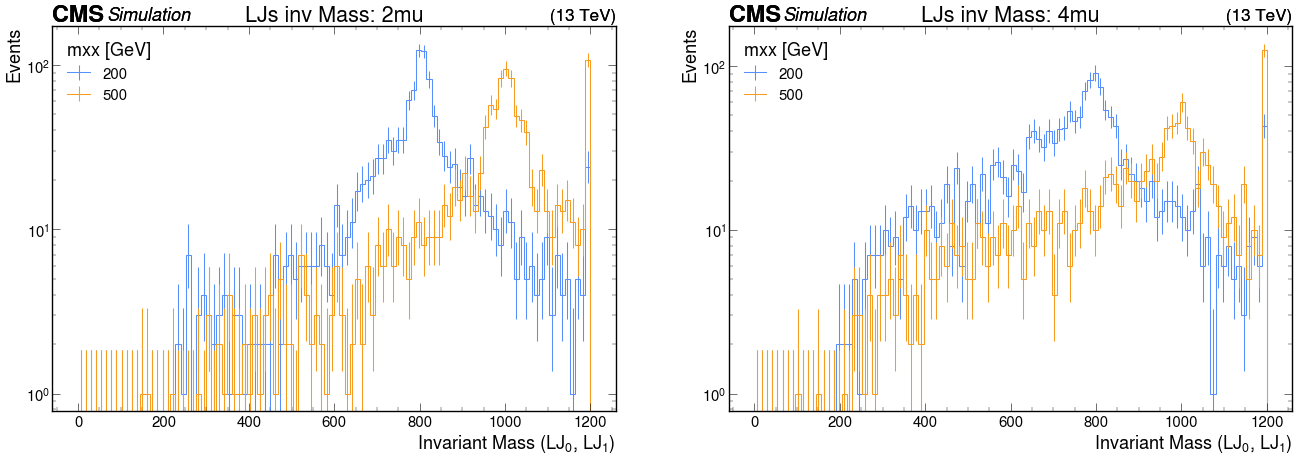

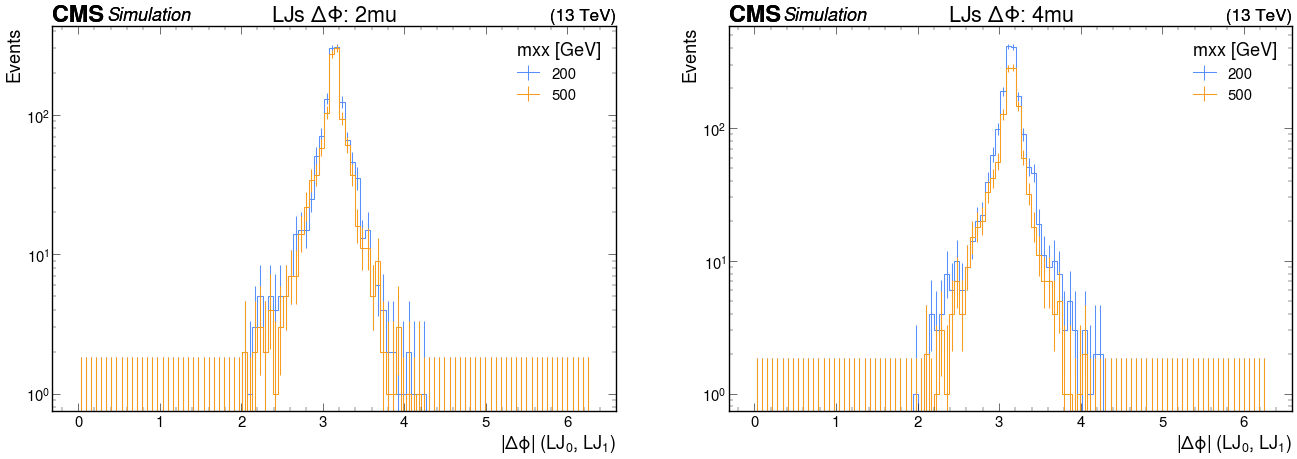

In [79]:
# LJ-LJ Variables signal only

htplot = ["lj_lj_invmass",
          "lj_lj_absdphi",
          # "lj_lj_absdR",
          # "lj_lj_absdeta"
         ]

htname = [r"LJs inv Mass",
          r"LJs $\Delta \Phi$",
          # r"LJs $\Delta R$",
          # r"LJs $\eta$",
         ]

ch = ch5

# changing Bs 4mu
for ik, ht in enumerate(htplot):
    plt.subplots(1, 2, figsize=(32, 10))

    plt.subplot(1, 2, 1)
    for ij, sss in enumerate(mxx2):
        utilities.plot(output[sss]["hists"][ht][ch7, :], label = lab_mx[ij])
    plt.title(htname[ik]+": 2mu")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)

    plt.subplot(1, 2, 2)
    for ij, sss in enumerate(mxx4):
        utilities.plot(output[sss]["hists"][ht][ch8, :], label = lab_mx[ij])

    plt.title(htname[ik]+": 4mu")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)


# for ij, sss in enumerate(mxx4):
#     for ik, ht in enumerate(htplot):
#         plt.subplots(1, 1, figsize=(16, 10))
#         for ch in cha:
#             utilities.plot(output[sss]["hists"][ht][ch, :], label = sss+ht+ch)#lab_mx[ij])


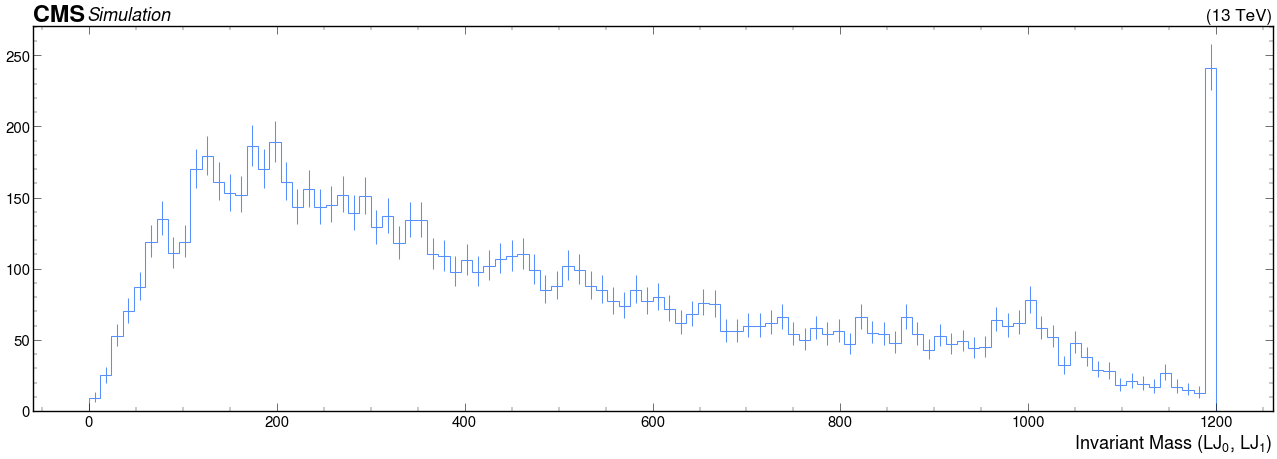

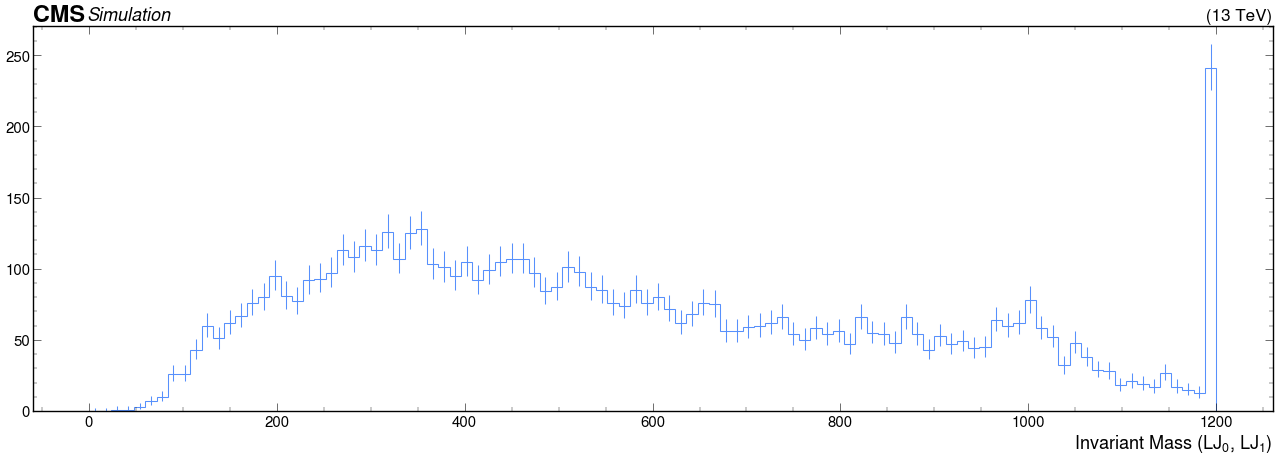

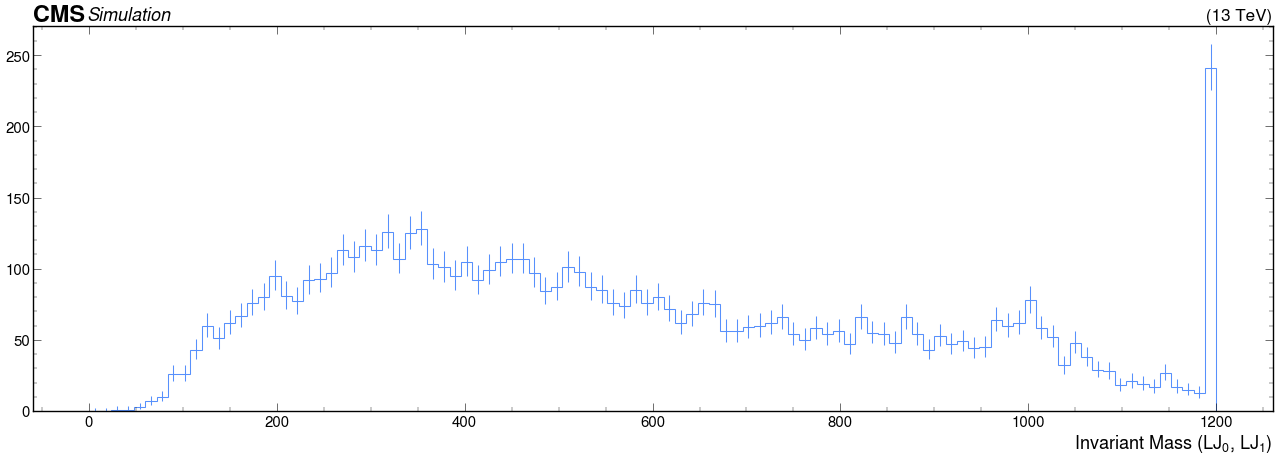

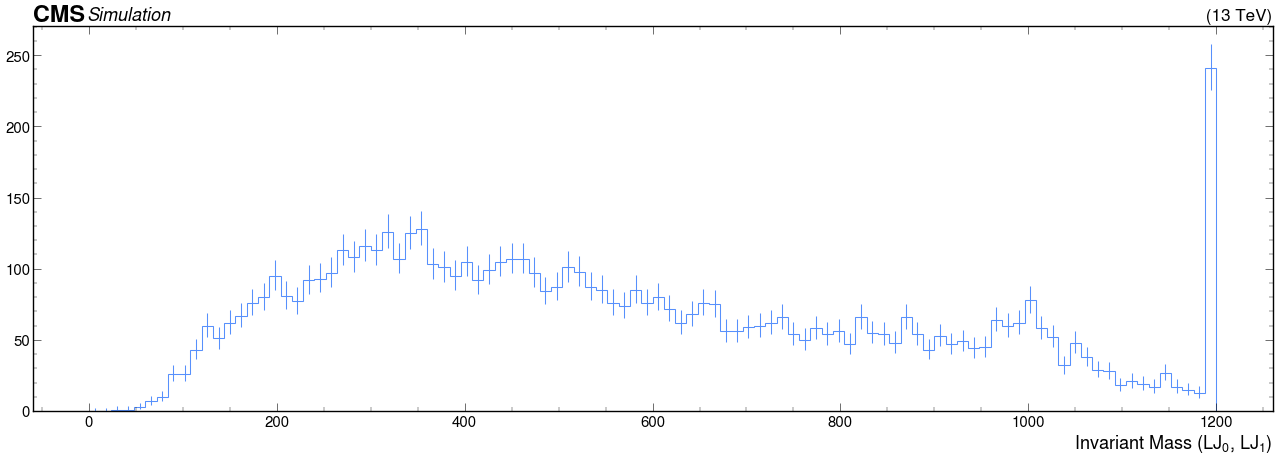

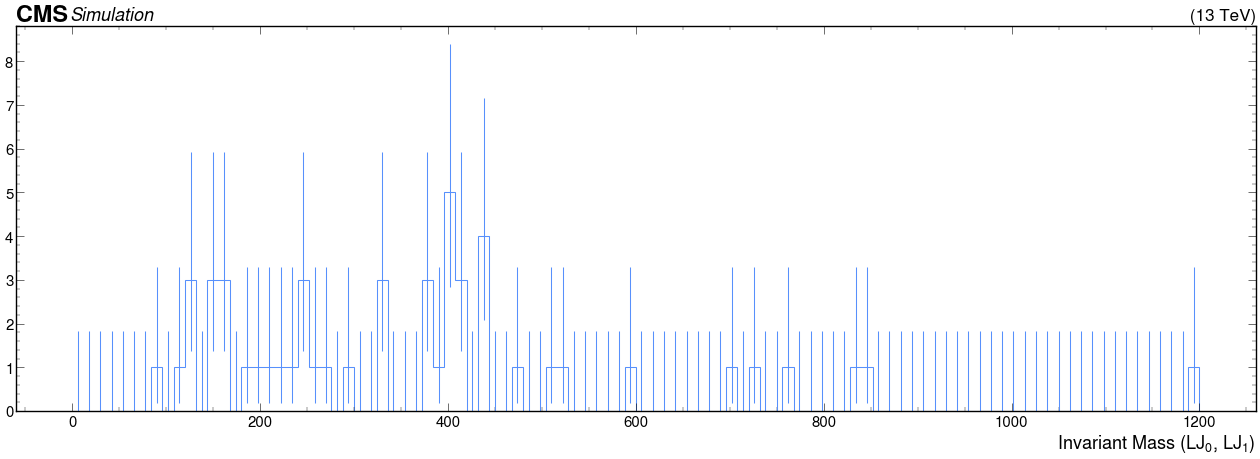

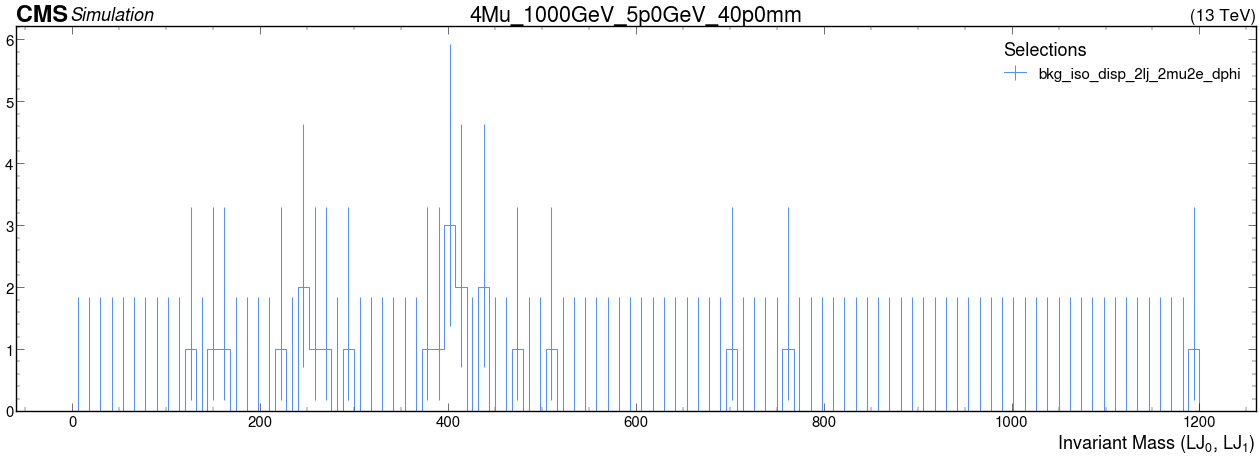

In [82]:
# LJ-LJ Variables signal only different channels

htplot = ["lj_lj_invmass",
          # "lj_lj_absdphi",
          # "lj_lj_absdR",
          # "lj_lj_absdeta"
         ]

htname = [r"LJs inv Mass",
          # r"LJs $\Delta \Phi$",
          # r"LJs $\Delta R$",
          # r"LJs $\eta$",
         ]
selname = ["nominal",
          "Isolation",
          "Displacement",
          ">2 LJ",
          "Channel",
          r"$\Delta \Phi$"
          ]
ch = ch5

# # changing Bs 4mu
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 2, figsize=(32, 10))

#     plt.subplot(1, 2, 1)
#     for ij, sss in enumerate(mxx2):
#         utilities.plot(output[sss]["hists"][ht][ch, :], label = lab_mx[ij])
#     plt.title(htname[ik]+": 2mu")
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title="mxx [GeV]", alignment="left", loc=0)

#     plt.subplot(1, 2, 2)
#     for ij, sss in enumerate(mxx4):
#         utilities.plot(output[sss]["hists"][ht][ch6, :], label = lab_mx[ij])

#     plt.title(htname[ik]+": 4mu")
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title="mxx [GeV]", alignment="left", loc=0)
#     # plt.savefig(f"clean_plots/ch5_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

cha2 = [ch1, ch2, ch3, ch4, ch5, ch7]
cha4 = [ch1, ch2, ch3, ch4, ch6, ch8]
ss2 = mxx2[0]
ss4 = mxx4[0]
# for ij, sss in enumerate(mxx4):
# for ik, ht in enumerate(htplot):
# plt.subplots(1, 1, figsize=(32, 10))
for ch in cha2:
    plt.subplots(1, 1, figsize=(32, 10))
    utilities.plot(output[sss]["hists"][ht][ch, :], label = ch)#lab_mx[ij])
plt.title(sss)
plt.legend(title="Selections", alignment="left", loc=0)

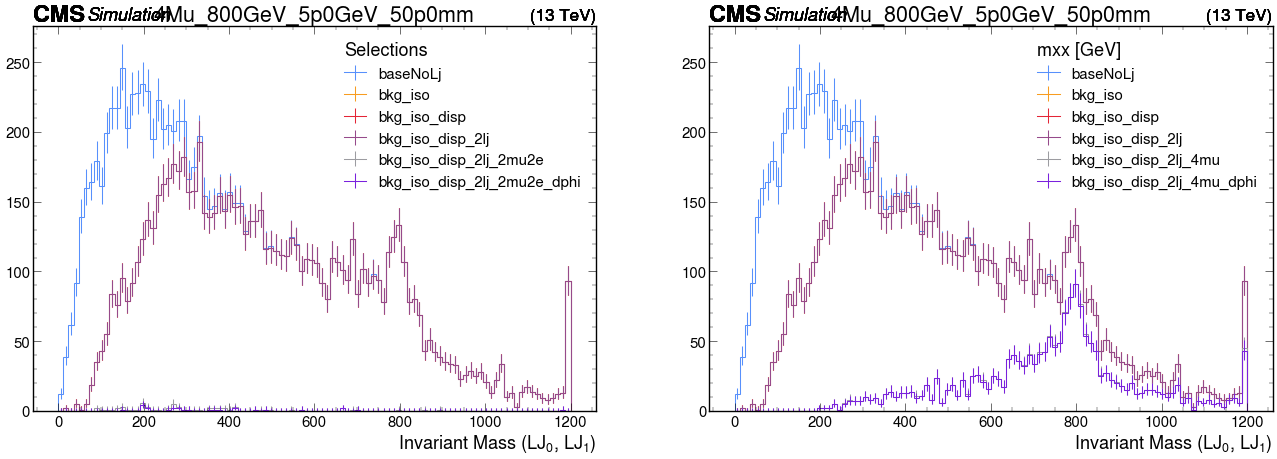

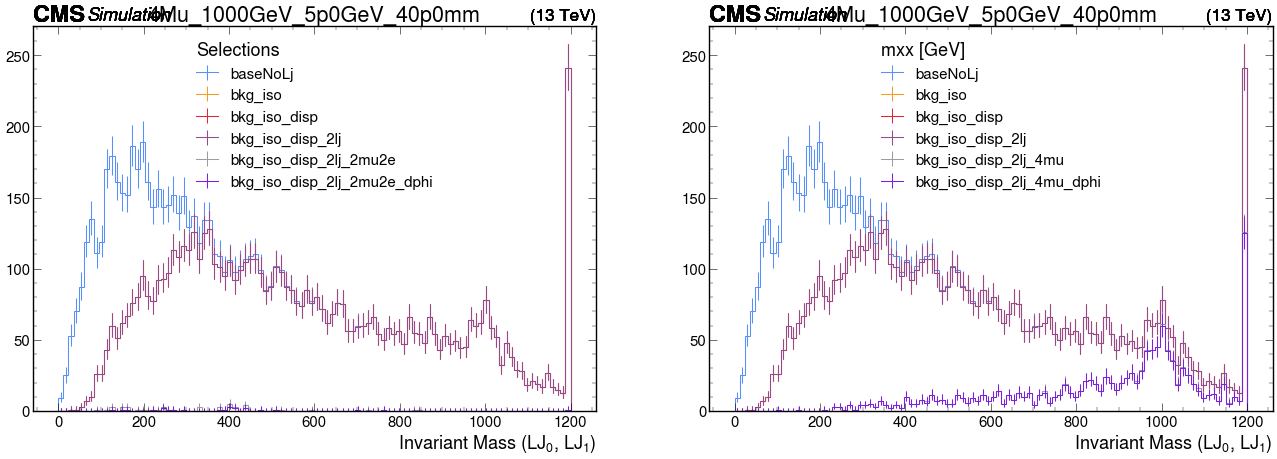

In [74]:
# LJ-LJ Variables signal only different channels

htplot = ["lj_lj_invmass",
          # "lj_lj_absdphi",
          # "lj_lj_absdR",
          # "lj_lj_absdeta"
         ]

htname = [r"LJs inv Mass",
          # r"LJs $\Delta \Phi$",
          # r"LJs $\Delta R$",
          # r"LJs $\eta$",
         ]
selname = ["nominal",
          "Isolation",
          "Displacement",
          ">2 LJ",
          "Channel",
          r"$\Delta \Phi$"
          ]
ch = ch5

# # changing Bs 4mu
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 2, figsize=(32, 10))

#     plt.subplot(1, 2, 1)
#     for ij, sss in enumerate(mxx2):
#         utilities.plot(output[sss]["hists"][ht][ch, :], label = lab_mx[ij])
#     plt.title(htname[ik]+": 2mu")
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title="mxx [GeV]", alignment="left", loc=0)

#     plt.subplot(1, 2, 2)
#     for ij, sss in enumerate(mxx4):
#         utilities.plot(output[sss]["hists"][ht][ch6, :], label = lab_mx[ij])

#     plt.title(htname[ik]+": 4mu")
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title="mxx [GeV]", alignment="left", loc=0)
#     # plt.savefig(f"clean_plots/ch5_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

cha2 = [ch1, ch2, ch3, ch4, ch5, ch7]
cha4 = [ch1, ch2, ch3, ch4, ch6, ch8]
ss2 = mxx2[0]
ss4 = mxx4[0]
for ij, sss in enumerate(mxx4):
    for ik, ht in enumerate(htplot):
        plt.subplots(1, 2, figsize=(32, 10))
        plt.subplot(1, 2, 1)
        for ch in cha2:
            utilities.plot(output[sss]["hists"][ht][ch, :], label = ch)#lab_mx[ij])
        plt.title(sss)
        plt.legend(title="Selections", alignment="left", loc=0)
    
        plt.subplot(1, 2, 2)
        for ch in cha4:
            utilities.plot(output[sss]["hists"][ht][ch, :], label = ch)#lab_mx[ij])
        plt.title(sss)
        plt.legend(title="mxx [GeV]", alignment="left", loc=0)


/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())
/usr/local/lib/python3.12/site-packages/mplhep/utils.py:652: RuntimeWarning: All sumw are zero!  Cannot compute meaningful error bars
  return np.abs(method_fcn(self.values(), variances) - self.values())


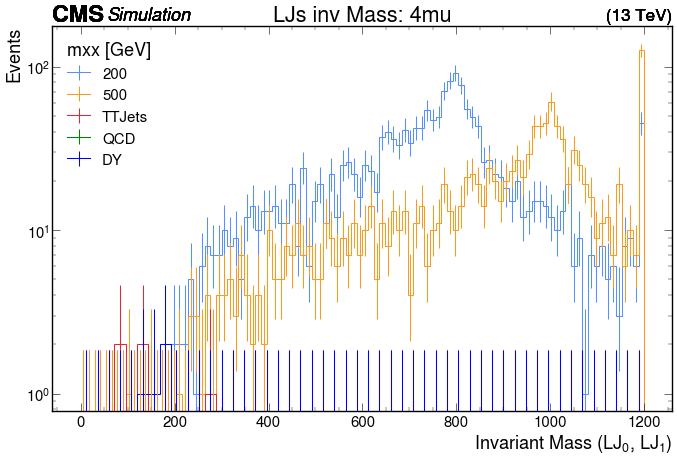

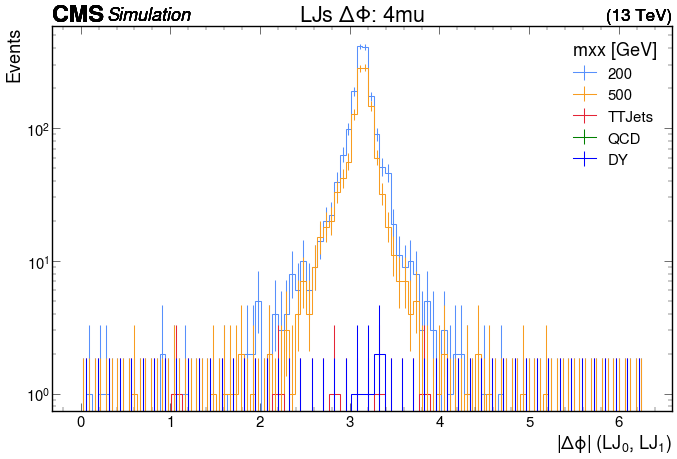

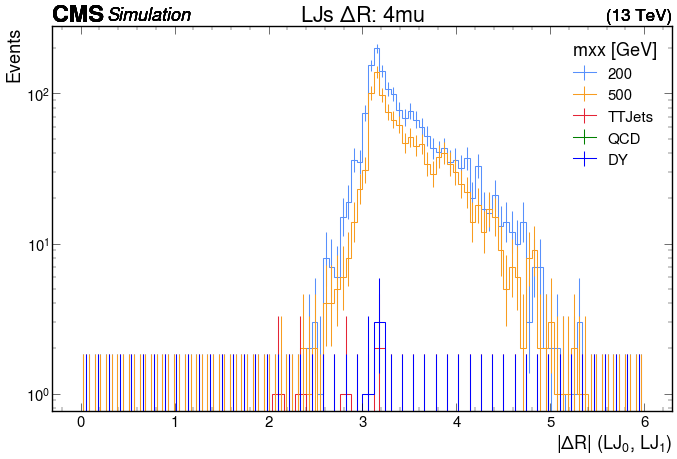

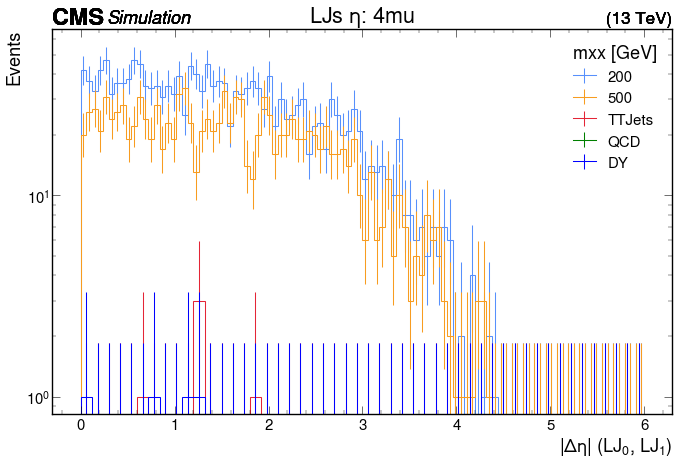

In [75]:
# LJ-LJ Variables signal + background
htplot = ["lj_lj_invmass",
          "lj_lj_absdphi",
          "lj_lj_absdR",
          "lj_lj_absdeta"
         ]

htname = [r"LJs inv Mass",
          r"LJs $\Delta \Phi$",
          r"LJs $\Delta R$",
          r"LJs $\eta$",
         ]


# changing Bs 4mu
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx4):
        utilities.plot(output[sss]["hists"][ht][ch6, :], label = lab_mx[ij])
        signal = output[sss]["hists"][ht][ch6, ::2j]

    TTJ = 0
    for ij, ttj in enumerate(bkgttj):
        TTJ = TTJ + output[ttj]["hists"][ht][ch6, ::2j]
    utilities.plot(TTJ, label = "TTJets")

    
    QCD = 0
    for qcd in bkgqcd:
        QCD = QCD + output[qcd]["hists"][ht][ch6, ::2j]
    utilities.plot(QCD, label = "QCD", density=False, color="green")

    DYJ = 0 
    for dyj in bkgdyj:
        DYJ = DYJ + output[dyj]["hists"][ht][ch6, ::2j]
    utilities.plot(DYJ, label = "DY", density=False, color="blue")
    # print(type(DYJ))
    # print(inspect.signature(utilities.plot))
    
    plt.title(htname[ik]+": 4mu")
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)


# changing Bs 2mu
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mxx2):
#         utilities.plot(output[sss]["hists"][ht][chan, :], label = lab_mx[ij])
#     for ij, sss in enumerate(bkgttj):
#         utilities.plot(output[sss]["hists"][ht][chan, :], label = sss)
#     for ij, sss in enumerate(bkgdyj):
#         utilities.plot(output[sss]["hists"][ht][chan, :], label = sss)
#     plt.title(htname[ik]+r": 2mu2e")
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    # plt.savefig(f"clean_plots/ch5_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

    
# # changing zd
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mzd4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# # changing lxy
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(lxy4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

In [76]:
# Process	Common Color	Hex
# DY/Z+jets	        Yellow/Gold	     #FFD700
# TTJets / ttbar  	Red	             #E74C3C
# QCD             	Blue	         #3498DB
# W+jets	            Green	         #2ECC71
# Diboson (WW/WZ/ZZ)	Purple	         #9B59B6
# Single Top	        Orange           #F39C12

# Signal	            Black          (#000000)
# Alternative signal	Dark magenta   (#8E44AD)
# Alternative signal	Dark blue      (#1F77B4)

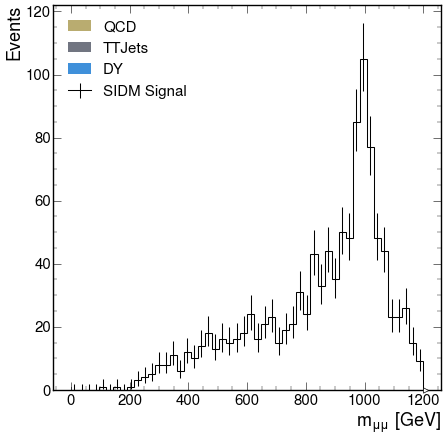

In [78]:
import matplotlib.pyplot as plt
import mplhep as hep

fig, ax = plt.subplots()

signal = output[sig_4mu[1]]["hists"]["lj_lj_invmass"][ch8, ::2j]
hep.histplot(
    signal,
    histtype="step",
    linewidth=1.5,
    color="black",
    label="SIDM Signal",
    ax=ax,
)

# Backgrounds (stacked)
hep.histplot(
    [DYJ, TTJ, QCD],
    stack=True,
    histtype="fill",
    color=["#3f90da", "#717581", "#b9ac70"],
    label=["DY", "TTJets", "QCD"],
    ax=ax,
)


ax.legend()
ax.set_xlabel(r"$m_{\mu\mu}$ [GeV]")
ax.set_ylabel("Events")
plt.show()

In [ ]:
# Muon Variables
htplot = ["muon_pt",
          "muon_dxy",
          "electron_pt",
          "dsaMuon_pt"
          "dsaMuon_dxy"
          # "muon_muon_dR",
         ]

htname = [r"Muon $p_T$",
          r"Muon $d_0$",
          r"ele $p_T$",
          r"dsamu $p_T$",
          r"dsamu $d_0$",
          # r"Muon $\Delta R$",
         ]

# changing Bs
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx4):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    plt.savefig(f"clean_plots/ch5_bkg_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing zd
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mzd4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing lxy
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(lxy4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

In [ ]:
# Plot backgrounds. Muon Variables
# htplot = ["muon_pt",
#           "muon_dxy",
#           "electron_pt",
#           "dsaMuon_pt"
#           # "dsa_pt"
#           # "muon_muon_dR",
#          ]

# htname = [r"Muon $p_T$",
#           r"Muon $d_0$",
#           r"ele $p_T$",
#           r"dsamu $p_T$",
#           # r"Muon $\Delta R$",
#          ]

# # changing Bs
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(bkgqcd+bkgdyj):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title="mxx [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing zd
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(mzd4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing lxy
# for ik, ht in enumerate(htplot):
#     plt.subplots(1, 1, figsize=(16, 10))
#     for ij, sss in enumerate(lxy4):
#         utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
#     plt.title(htname[ik])
#     plt.ylabel("Events")
#     plt.yscale("log")
#     plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
#     plt.savefig(f"clean_plots/ch5_bkg_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")

In [ ]:
# Dark Photon Variables

htplot = ["genAs_pt", "genA_n", "genAs_eta", "genAs_phi", "genAs_mass"]
htname = [r"Dark Photon $p_T$", r"Number of $z_D$", r"Dark Photon $\eta$", r"Dark Photon $\phi$", r"Dark Photon Mass"]

#changing Bs mass
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx2):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    plt.savefig(f"clean_plots/ch5_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

#changing lxy
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(lxy2):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
    plt.savefig(f"clean_plots/ch5_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

In [ ]:
# LJ-LJ Variables
htplot = ["lj_lj_absdphi",
          "lj_lj_invmass",
          "lj_lj_absdR",
          "lj_lj_absdeta"
         ]

htname = [r"LJs $\Delta \Phi$",
          r"LJs inv Mass$",
          r"LJs $\Delta R$",
          r"LJs $\eta$",
         ]

# changing Bs
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mxx4):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_mx[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title="mxx [GeV]", alignment="left", loc=0)
    plt.savefig(f"clean_plots/ch5_{vr}_mxx_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing zd
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(mzd4):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_zd[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"$z_D$ [GeV]", alignment="left", loc=0)
    plt.savefig(f"clean_plots/ch5_{vr}_mzd_{ht}_.pdf", bbox_inches="tight", dpi=300)

# changing lxy
for ik, ht in enumerate(htplot):
    plt.subplots(1, 1, figsize=(16, 10))
    for ij, sss in enumerate(lxy4):
        utilities.plot(output[sss]["hists"][ht][ch1, :], label = lab_xy[ij])
    plt.title(htname[ik])
    plt.ylabel("Events")
    plt.yscale("log")
    plt.legend(title=r"$L_{xy}$ [cm]", alignment="left", loc=0)
    plt.savefig(f"clean_plots/ch5_{vr}_lxy_{ht}_.pdf", bbox_inches="tight", dpi=300)

In [ ]:
# # 2mu hist
# h_names = ["Gen Electron pT",
#            "d0", 
#            "Delta R between Electrons",
#            "$Z_D$ mass", 
#            "$m_{xx}$ mass",
#            ]

# h_to_plot = ["genE_pt",
#              "genE_dxy",
#              "genE_genE_dR",
#              "genA_from_genEs_mass",
#              "genBS_from_genAs_mass",
#              ]

# var = [mxx2, mzd2, lxy2]
# svr = ["mxx", "mzd", "lxy"]

# for sv, mm in enumerate(var):
#     for hn, ht in enumerate(h_to_plot):
#         plt.subplots(1, 1, figsize=(16, 10))
#         for sss in mm:
#             utilities.plot(output[sss]["hists"][ht][ch1, :], label = sss)
#         plt.title(h_names[hn])
#         plt.ylabel("Events")
#         plt.yscale("log")
#         plt.legend(alignment="left", loc=0)
#         # plt.savefig(f"clean_plots/ch5_{ht}_{svr[sv]}_"+vr+".png", bbox_inches="tight")
#         plt.savefig(f"clean_plots/ch5_{ht}_{svr[sv]}_"+vr+".pdf", bbox_inches="tight")

In [ ]:
#4mu hist
# h_names = ["Gen Muon pT"]
# h_to_plot = ["genMu_pt",]

# h_names = ["Gen Muon pT", 
#            "do",  
#            "Delta R between Muons", 
#            "$Z_D$ mass", 
#            "$m_{xx}$ mass", 
#            ]

# h_to_plot = ["genMu_pt", 
#              "genMu_dxy", 
#              "genMu_genMu_dR",
#              "genA_from_genMus_mass", 
#              "genBS_from_genAs_mass", 
#             ]

# var = [mxx4, mzd4, lxy4]
# svr = ["mxx", "mzd", "lxy"]

# for sv, mm in enumerate(var):
#     for hn, ht in enumerate(h_to_plot):
#         plt.subplots(1, 1, figsize=(16, 10))
#         for sss in mm:
#             utilities.plot(output[sss]["hists"][ht][ch1, :], label = sss)
#         plt.title(h_names[hn])
#         plt.ylabel("Events")
#         plt.yscale("log")
#         plt.legend(alignment="left", loc=0)
#         # plt.savefig(f"clean_plots/ch5_{ht}_{svr[sv]}_"+vr+".png", bbox_inches="tight")
#         plt.savefig(f"clean_plots/ch5_{ht}_{svr[sv]}_"+vr+".pdf", bbox_inches="tight", dpi=300)

In [ ]:
raise SystemExit("Notebook stopped intentionally after this cell.")